Import the dataset and setup git

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.
Path to dataset files: /kaggle/input/fake-and-real-news-dataset


In [2]:
import os

# List the contents of the downloaded dataset directory
dataset_files = os.listdir(path)
print(f"Files in the dataset directory '{path}':\n{dataset_files}")

Files in the dataset directory '/kaggle/input/fake-and-real-news-dataset':
['True.csv', 'Fake.csv']


Visualize the dataset

In [3]:
import numpy as np
import pandas as pd

np.random.seed(42)

true_news_df = pd.read_csv(os.path.join(path, 'True.csv'))
fake_news_df = pd.read_csv(os.path.join(path, 'Fake.csv'))

print("First 5 rows of True News dataset:")
display(true_news_df.head())

print("\nFirst 5 rows of Fake News dataset:")
display(fake_news_df.head())

First 5 rows of True News dataset:


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"



First 5 rows of Fake News dataset:


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [4]:
# Add 'truth' column to true_news_df with value 1
true_news_df['truth'] = 1

# Add 'truth' column to fake_news_df with value 0
fake_news_df['truth'] = 0

# Combine the dataframes
combined_df = pd.concat([true_news_df, fake_news_df], ignore_index=True)

print("Combined DataFrame head:")
display(combined_df.head())

print("\nCombined DataFrame tail:")
display(combined_df.tail())

print(f"\nShape of combined DataFrame: {combined_df.shape}")
print(f"Number of true news entries: {combined_df[combined_df['truth'] == 1].shape[0]}")
print(f"Number of fake news entries: {combined_df[combined_df['truth'] == 0].shape[0]}")

Combined DataFrame head:


,title,text,subject,date,truth
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1



Combined DataFrame tail:


,title,text,subject,date,truth
44893,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0
44894,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0
44895,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0
44896,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0
44897,10 U.S. Navy Sailors Held by Iranian Military ...,21st Century Wire says As 21WIRE predicted in ...,Middle-east,"January 12, 2016",0



Shape of combined DataFrame: (44898, 5)
Number of true news entries: 21417
Number of fake news entries: 23481


Randomize dataset, split into train/test

In [5]:
# 1. Randomize combined_df so rows are in random order
combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

# 2. Create master with only text and truth columns
master = combined_df[["text", "truth"]].copy()

# 3. 70% train / 30% test split
from sklearn.model_selection import train_test_split

train, test = train_test_split(master, test_size=0.3, random_state=42)

print(f"Master shape: {master.shape}")
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

Master shape: (44898, 2)
Train shape: (31428, 2)
Test shape: (13470, 2)


## Fine-Tuning RoBERTa for Fake News Detection

We fine-tune a pretrained RoBERTa transformer on the training set and evaluate on the held-out test set. Following the same approach as the BERT model example, we use a very small learning rate (1e-5) to gently update the pretrained weights without destroying what the model already learned.

In [6]:
pip install --quiet keras-hub

In [7]:
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'

import keras
import keras_hub

keras.utils.set_random_seed(42)

### Load the Pretrained RoBERTa Classifier

We load `roberta_base_en` (~124M parameters) from Keras Hub and add a 2-class classification head on top (fake=0, real=1). All backbone weights are set to trainable so the whole model adapts to our task.

In [8]:
classifier = keras_hub.models.RobertaClassifier.from_preset(
    "roberta_base_en",
    num_classes=2,
)

classifier.backbone.trainable = True
classifier.summary()

100%|██████████| 445/445 [00:00<00:00, 861kB/s]


100%|██████████| 474M/474M [00:35<00:00, 14.1MB/s]


Preprocessor: "roberta_text_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ roberta_tokenizer (RobertaTokenizer)                          │                       Vocab size: 50,265 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "roberta_text_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ roberta_backbone              │ (None, None, 768)         │     124,052,736 │ padding_mask[0][0],        │
│ (RobertaBackbone)             │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item (GetItem)            │ (None, 768)               │               0 │ roberta_backbone[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dropout (Dropout)      │ (None, 768)               │               0 │ get_item[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dense (Dense)          │ (None, 768)               │         590,592 │ pooled_dropout[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output_dropout (Dropout)      │ (None, 768)               │               0 │ pooled_dense[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 2)                 │           1,538 │ output_dropout[0][0]       │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 124,644,866 (475.48 MB)

 Trainable params: 124,644,866 (475.48 MB)

 Non-trainable params: 0 (0.00 B)

### Compile the Model

We use `SparseCategoricalCrossentropy` because our labels are integers (0 or 1). A very small learning rate (1e-5) is critical — too large and we would overwrite the rich pretrained representations.

In [9]:
classifier.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.Adam(1e-5),
    metrics=["accuracy"],
    jit_compile=True,
)

### Prepare Text and Labels

Extract the `text` column and `truth` labels as plain Python lists. `keras-hub` preprocessors accept raw strings directly, so no manual tokenization is needed.

In [10]:
from sklearn.model_selection import train_test_split

train_texts  = train["text"].tolist()
train_labels = train["truth"].tolist()

# Split the training data further into training and validation sets
x_train_fit, x_val_fit, y_train_fit, y_val_fit = train_test_split(
    train_texts, train_labels, test_size=0.1, random_state=42
)

test_texts  = test["text"].tolist()
test_labels = test["truth"].tolist()

print(f"Training samples (for fit): {len(x_train_fit)}")
print(f"Validation samples (for fit): {len(x_val_fit)}")
print(f"Test samples:     {len(test_texts)}")

Training samples (for fit): 28285
Validation samples (for fit): 3143
Test samples:     13470


### Train the Model

Fine-tune for 5 epochs using 10% of the training data as a validation split to monitor for overfitting. With 31k training samples this will be slow on CPU — use a GPU runtime if available.

In [11]:
history = classifier.fit(
    x=x_train_fit,
    y=y_train_fit,
    batch_size=16,
    epochs=5,
    validation_data=(x_val_fit, y_val_fit), # Use pre-split validation data
)

Epoch 1/5
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 348s 147ms/step - accuracy: 0.9966 - loss: 0.0115 - val_accuracy: 0.9994 - val_loss: 0.0032
Epoch 2/5
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 197s 110ms/step - accuracy: 0.9999 - loss: 8.7447e-04 - val_accuracy: 1.0000 - val_loss: 1.9157e-05
Epoch 3/5
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 198s 111ms/step - accuracy: 1.0000 - loss: 3.5393e-04 - val_accuracy: 1.0000 - val_loss: 9.8684e-06
Epoch 4/5
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 197s 111ms/step - accuracy: 1.0000 - loss: 3.7219e-04 - val_accuracy: 1.0000 - val_loss: 1.1656e-04
Epoch 5/5
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 197s 111ms/step - accuracy: 1.0000 - loss: 3.3834e-04 - val_accuracy: 1.0000 - val_loss: 5.2842e-06


In [12]:
history = classifier.fit(
    x=x_train_fit,
    y=y_train_fit,
    batch_size=16,
    epochs=1,
    validation_data=(x_val_fit, y_val_fit), # Use pre-split validation data
)

1768/1768 ━━━━━━━━━━━━━━━━━━━━ 199s 111ms/step - accuracy: 0.9996 - loss: 0.0022 - val_accuracy: 1.0000 - val_loss: 3.6969e-05


### Visualize Training Dynamics

Plot loss and accuracy curves to see how the model improved across epochs and whether it is overfitting.

In [ ]:
import matplotlib.pyplot as plt

train_loss = history.history["loss"]
val_loss   = history.history["val_loss"]
train_acc  = history.history["accuracy"]
val_acc    = history.history["val_accuracy"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_loss, label="Train Loss")
axes[0].plot(val_loss,   label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].set_title("Training & Validation Loss")

axes[1].plot(train_acc, label="Train Accuracy")
axes[1].plot(val_acc,   label="Val Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].set_title("Training & Validation Accuracy")

plt.tight_layout()
plt.show()

### Evaluate on the Test Set

Run the final trained model against the held-out test set to get an unbiased accuracy estimate.

In [14]:
test_loss, test_acc = classifier.evaluate(x=test_texts, y=test_labels)

print(f"\nTest Accuracy:  {test_acc:.4f}")
print(f"Test Loss:      {test_loss:.4f}")

421/421 ━━━━━━━━━━━━━━━━━━━━ 42s 77ms/step - accuracy: 0.9999 - loss: 6.3965e-04

Test Accuracy:  0.9999
Test Loss:      0.0006


In [ ]:
import tensorflow as tf
import numpy as np

def predict_news_truthfulness(text_paragraph):
    """
    Predicts if a given text paragraph is true or fake using the trained classifier.

    Args:
        text_paragraph (str): The input text paragraph.

    Returns:
        str: 'True' if the model predicts true, 'Fake' if the model predicts fake.
    """
    # The classifier expects a list of strings
    predictions = classifier.predict([text_paragraph])

    # Apply softmax to get probabilities from logits
    probabilities = tf.nn.softmax(predictions).numpy()

    # Get the predicted class (0 for fake, 1 for true)
    predicted_class = np.argmax(probabilities, axis=1)[0]

    if predicted_class == 1:
        return "True"
    else:
        return "Fake"

# You can also try with a custom text:
custom_text = "In a regulatory move that could significantly disrupt high-frequency trading markets, the Securities and Exchange Commission unveiled a comprehensive proposal on Wednesday aimed at prohibiting the use of quantum-state arbitrage by institutional investors. The controversial practice, which leverages early-stage quantum processors to execute probabilistic equity trades milliseconds before traditional optical networks can register the data, has been blamed for a series of unexplained, localized liquidity crunches over the past fiscal year. SEC regulatory officials stated that the updated framework is necessary to ensure fundamental market parity, arguing that standard algorithmic traders are currently operating at an insurmountable latency disadvantage. Wall Street lobbying groups, including the Quantitative Trading Alliance, immediately pushed back against the draft legislation, characterizing the proposed rule as a gross administrative overreach that would stifle domestic technological innovation and drive capital to less regulated overseas exchanges. The morning announcement triggered a moderate sell-off in the tech-heavy Nasdaq composite, as shares of major quantum-computing hardware suppliers and proprietary trading firms fell sharply in late afternoon trading. The commission is expected to open the 500-page proposal for a standard 90-day public comment period before scheduling a final compliance vote in the fourth quarter."
print(f"Prediction for custom_text: {predict_news_truthfulness(custom_text)}")

Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.
--- Descriptive Statistics for True News Text Lengths ---


,text_length
count,21417.000000
mean,2383.278517
std,1684.835730
min,1.000000
25%,914.000000
50%,2222.000000
75%,3237.000000
max,29781.000000



--- Descriptive Statistics for Fake News Text Lengths ---


,text_length
count,23481.000000
mean,2547.396235
std,2532.884399
min,1.000000
25%,1433.000000
50%,2166.000000
75%,3032.000000
max,51794.000000


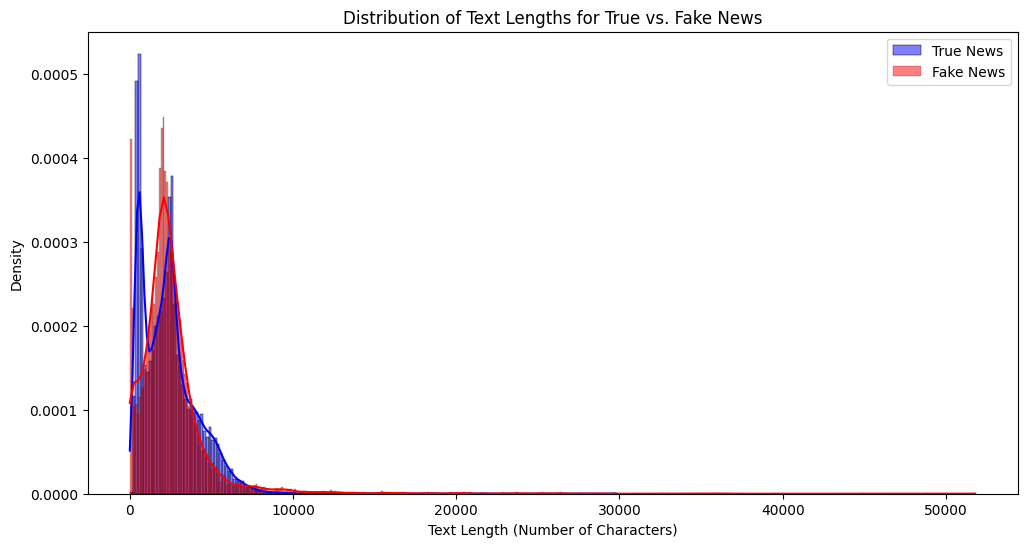

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Added
import os # Added
import kagglehub # Added

# Ensure the dataset path and dataframes are loaded
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset") # Added
true_news_df = pd.read_csv(os.path.join(path, 'True.csv')) # Added
fake_news_df = pd.read_csv(os.path.join(path, 'Fake.csv')) # Added

# Calculate text lengths
true_news_df['text_length'] = true_news_df['text'].apply(len)
fake_news_df['text_length'] = fake_news_df['text'].apply(len)

print("--- Descriptive Statistics for True News Text Lengths ---")
display(true_news_df['text_length'].describe())

print("\n--- Descriptive Statistics for Fake News Text Lengths ---")
display(fake_news_df['text_length'].describe())

# Plotting the distributions
plt.figure(figsize=(12, 6))
sns.histplot(true_news_df['text_length'], color='blue', label='True News', kde=True, stat='density', alpha=0.5)
sns.histplot(fake_news_df['text_length'], color='red', label='Fake News', kde=True, stat='density', alpha=0.5)
plt.title('Distribution of Text Lengths for True vs. Fake News')
plt.xlabel('Text Length (Number of Characters)')
plt.ylabel('Density')
plt.legend()
plt.show()

In [17]:
import numpy as np

# Select 200 random examples from the training data
num_examples = 200
random_indices = np.random.choice(len(x_train_fit), num_examples, replace=False)

x_train_subset = [x_train_fit[i] for i in random_indices]
y_train_subset = [y_train_fit[i] for i in random_indices]

print(f"Retraining with {num_examples} random samples...")

history_subset = classifier.fit(
    x=x_train_subset,
    y=y_train_subset,
    batch_size=16,
    epochs=1,
    validation_data=(x_val_fit, y_val_fit), # Use pre-split validation data
)

print("\nValidation Accuracy after retraining with subset:")
print(f"Accuracy: {history_subset.history['val_accuracy'][-1]:.4f}")
print(f"Loss: {history_subset.history['val_loss'][-1]:.4f}")

Retraining with 200 random samples...
13/13 ━━━━━━━━━━━━━━━━━━━━ 74s 6s/step - accuracy: 1.0000 - loss: 5.0915e-05 - val_accuracy: 1.0000 - val_loss: 3.6004e-05

Validation Accuracy after retraining with subset:
Accuracy: 1.0000
Loss: 0.0000


In [18]:
test_loss_subset, test_acc_subset = classifier.evaluate(x=test_texts, y=test_labels)

print(f"\nTest Accuracy (200 sample model):  {test_acc_subset:.4f}")
print(f"Test Loss (200 sample model):      {test_loss_subset:.4f}")

421/421 ━━━━━━━━━━━━━━━━━━━━ 27s 58ms/step - accuracy: 0.9999 - loss: 6.4116e-04

Test Accuracy (200 sample model):  0.9999
Test Loss (200 sample model):      0.0006
